# Predição de Gênero - Análise de Reviews

- **Aluno:** Pedro Yutaro Mont Morency Nakamura  
- **Data:** 17/05/2026
- **Objetivo:** Desenvolver um modelo de classificação para predizer gênero...

## 0. Configurações e Importações de Dependẽncias e Dados

In [1]:
import os
import pickle
import pandas as pd
import numpy as np

# Visualização de Dados
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-Processamento
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import spacy
from tqdm import tqdm
from spacy.matcher import Matcher

# Estruturas e estatística
from scipy.stats import loguniform, randint, uniform, mannwhitneyu

# Classificadores e seleção
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler

# Validação e busca de hiperparâmetros
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

### 0.1 Configuração de Gráficos

In [2]:
# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

### 0.2 Carregamento do modelo SpaCy para Português

In [84]:
try:
    # Carrega apenas componentes necessarios para POS/lemmas.
    disable=["parser", "ner"]
    nlp = spacy.load("pt_core_news_lg", disable=disable)
    print("✅ SpaCy pt_core_news_lg carregado com sucesso!")
except Exception as e:
    print(f"❌ Erro ao carregar o modelo: {e}")

✅ SpaCy pt_core_news_lg carregado com sucesso!


### 0.3 Importação dos Datasets

In [5]:
# Caminhos para os dados
TRAIN_PATH = './data/treino.csv'
VALIDATION_PATH = './data/validacao.csv'

In [6]:
# Carregando CSVs
df_train = pd.read_csv(TRAIN_PATH, encoding='utf-8', low_memory=False)
df_val = pd.read_csv(VALIDATION_PATH, encoding='utf-8', low_memory=False)

## 1. Exploração dos Dados

In [ ]:
print(f"Treino: {len(df_train)} reviews")
print(f"Distribuição de gênero:\n{df_train['reviewer_gender'].value_counts()}")
df_train.head()

Treino: 76942 reviews
Distribuição de gênero:
reviewer_gender
M    39699
F    37243
Name: count, dtype: int64


,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state
0,2018-01-25 15:09:27,a06d0380bcd447431774739131312d3532e1018988da8c...,129610281,"iPhone 7 Plus 128GB dourado Tela Retina HD 5,5...",apple,Celulares e Smartphones,Smartphone,Iphone,3,Yes,É Verdade Mesmo Gente Essa Promocao? To queren...,1994.0,F,BA
1,2018-05-14 16:20:25,62bbbab0822b6917233e8a9846dc3e7acbdfe6b4df788a...,120934895,"TV LED 32"" Sony KDL-32R305B HD com Conversor D...",sony,TV e Home Theater,TV,Marca conceituada,3,Yes,"Acredito ser uma Boa TV, não tenho como ava...",1965.0,M,BA
2,2018-05-19 15:43:40,27908d4eea73f655ca4d50adc1c373efccc3b748d4a779...,15844032,Suporte P/ Notebook C/ Cooler Gamer Warrior - ...,NaN,Informática e Acessórios,Peças para Notebook,Excelente aquisição,5,Yes,A compra do produto confirmou a qualidade de o...,1951.0,M,PE
3,2018-01-14 14:35:10,b1ddb4c179231ffb650097bec1ad8033dc8c2bad60a846...,132444050,Smartphone Motorola Moto G 5S Dual Chip Androi...,NaN,Celulares e Smartphones,Smartphone,Atende as necessidades,4,Yes,Celular intermediário de bom custo benefício. ...,1978.0,F,PA
4,2018-03-08 12:40:03,4188541be9484e0e49c4803e767354c3e84e419a2d23da...,132522724,Panela de Pressão Elétrica Digital Philco Pppv...,NaN,Eletroportáteis,Panela Elétrica,Muito bom,4,Yes,"Prática, fácil de limpar, excelente produto. R...",1980.0,F,RJ


In [8]:
print(f"Validação: {len(df_val)} reviews")
print(f"Distribuição de gênero:\n{df_val['reviewer_gender'].value_counts()}")
df_val.head()

Validação: 25647 reviews
Distribuição de gênero:
reviewer_gender
M    13233
F    12414
Name: count, dtype: int64


,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state
0,2018-04-30 19:24:28,fabc81c4fa9efa6867a78d82ce2713099ed1eea5df9d80...,31575567,Vela Led Decorativa 15cm Pilha Amarelo-Der/07-...,NaN,Decoração,Luminária,Efeito bonito,4,Yes,Gostei do efeito. Parece uma vela de verdade. ...,1954.0,F,RS
1,2018-04-27 17:48:48,6fbac43a75fd2dbb7e74687472779b74cc9602a566be74...,132474081,Smartphone Moto G 5S Dual Chip Android 7.0 Tel...,NaN,Celulares e Smartphones,Smartphone,"Hardware fraco, mas conjunto excelente.",4,Yes,Não me arrependo de ter comprado o G5S à conco...,1996.0,M,RJ
2,2018-03-06 18:45:17,e85bcc86d48fdd1462bada4d5f4f19cde9f86acf157992...,16215756,Cadeira Amanda Medalhao Marrom Rivatti,NaN,Móveis,Cadeira,Excelente qualidade,5,Yes,"Produto recebido dentro do prazo, acondicionad...",1973.0,F,SP
3,2018-05-18 07:00:58,5e054a67eb8f4ab98b0e53c532843f65a49ed17aef8214...,12298660,Kit 2 peças Holofote Refletor Super Led Duplo ...,NaN,Casa e Construção,Iluminação,Produto de Ótima qualidade,4,Yes,"Produto de Ótima qualidade, atendeu todas as m...",1969.0,M,SP
4,2018-04-21 06:31:51,9b22f24daed6d47b570be15dc928f8d522e8e1315f7d0c...,132537782,Smartphone Samsung Galaxy J7 Pro Android 7.0 T...,NaN,Celulares e Smartphones,Smartphone,Satisfeito,5,Yes,"Muito bom aparelho. Fotos e vídeos perfeitos, ...",1973.0,M,SP


### 3.1 Contagem de valores e tipos

In [8]:
print('\n<===== TRAIN DATAFRAME =====>')
df_train.info()


<===== TRAIN DATAFRAME =====>
<class 'pandas.DataFrame'>
RangeIndex: 76942 entries, 0 to 76941
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   submission_date        76942 non-null  str    
 1   reviewer_id            76942 non-null  str    
 2   product_id             76942 non-null  str    
 3   product_name           76903 non-null  str    
 4   product_brand          24162 non-null  str    
 5   site_category_lv1      76942 non-null  str    
 6   site_category_lv2      74687 non-null  str    
 7   review_title           76776 non-null  str    
 8   overall_rating         76942 non-null  int64  
 9   recommend_to_a_friend  76932 non-null  str    
 10  review_text            75056 non-null  str    
 11  reviewer_birth_year    75753 non-null  float64
 12  reviewer_gender        76942 non-null  str    
 13  reviewer_state         76942 non-null  str    
dtypes: float64(1), int64(1), str(12)
m

In [9]:
print('\n<===== VALIDATION DATAFRAME =====>')
df_val.info()


<===== VALIDATION DATAFRAME =====>
<class 'pandas.DataFrame'>
RangeIndex: 25647 entries, 0 to 25646
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   submission_date        25647 non-null  str    
 1   reviewer_id            25647 non-null  str    
 2   product_id             25647 non-null  int64  
 3   product_name           25629 non-null  str    
 4   product_brand          8048 non-null   str    
 5   site_category_lv1      25645 non-null  str    
 6   site_category_lv2      24875 non-null  str    
 7   review_title           25598 non-null  str    
 8   overall_rating         25647 non-null  int64  
 9   recommend_to_a_friend  25646 non-null  str    
 10  review_text            25044 non-null  str    
 11  reviewer_birth_year    25242 non-null  float64
 12  reviewer_gender        25647 non-null  str    
 13  reviewer_state         25647 non-null  str    
dtypes: float64(1), int64(2), str(

#### Verificando Valores Nulos

In [10]:
df_train.isna().sum()

submission_date              0
reviewer_id                  0
product_id                   0
product_name                39
product_brand            52780
site_category_lv1            0
site_category_lv2         2255
review_title               166
overall_rating               0
recommend_to_a_friend       10
review_text               1886
reviewer_birth_year       1189
reviewer_gender              0
reviewer_state               0
dtype: int64

In [11]:
df_val.isna().sum()

submission_date              0
reviewer_id                  0
product_id                   0
product_name                18
product_brand            17599
site_category_lv1            2
site_category_lv2          772
review_title                49
overall_rating               0
recommend_to_a_friend        1
review_text                603
reviewer_birth_year        405
reviewer_gender              0
reviewer_state               0
dtype: int64

Commo é possível observar, em ambos os datasets há presença de valores nulos referente ao texto. Registros sem conteúdo textual devem ser removidos.

#### Perguntas Norteadoras:
- Q1: A marca do produto (mesmo senddo apeans 32%), possui alguma correlação com o gênero do reviwer?
- Q2: Gênero vs. Categorias (site_category_lv1): Existem categorias de produtos onde um gênero comenta mais que o outro? (Ex: Maquiagem vs. Ferramentas)
- Q3: Gênero vs. Avaliação (overall_rating): Homens ou mulheres tendem a ser mais críticos ou elogiosos nas estrelas?.
- Q4: Existe uma diferença estatisticamente relevante no tamanho das mensagens escritas por homens e mulheres?.

#### Filtro inicial: remover reviews sem texto para não enviesar a análise de tamanho


Antes de analisar, precisamos tratar os nulos no texto e criar a métrica de tamanho de mensagem.

In [9]:
df_train_eda = df_train.dropna(subset=['review_text']).copy()

#### Criando métricas de texto

In [10]:
df_train_eda['text_len'] = df_train_eda['review_text'].str.len()
df_train_eda['word_count'] = df_train_eda['review_text'].apply(lambda x: len(str(x).split()))

### Q1: A marca do produto possui correlação com o gênero?

OBS: Mesmo com apenas 32% de preenchimento, as marcas podem indicar nichos específicos.

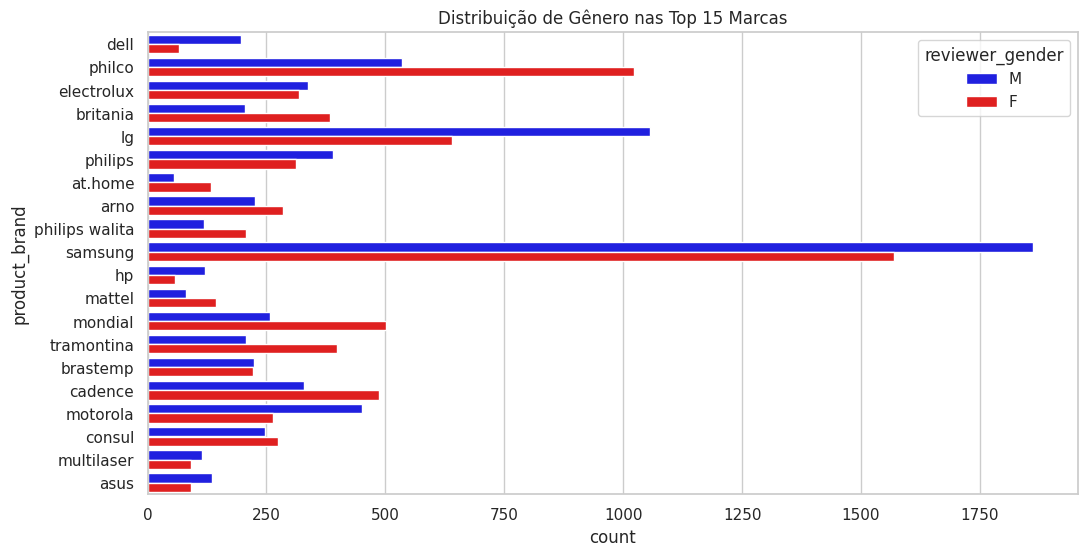

In [26]:
# Analisando as N marcas mais frequentes (onde não é nulo)
N_BRANDS = 20
top_brands = df_train_eda['product_brand'].value_counts().nlargest(N_BRANDS).index
df_brands = df_train_eda[df_train_eda['product_brand'].isin(top_brands)]

plt.figure(figsize=(12, 6))
sns.countplot(data=df_brands, y='product_brand', hue='reviewer_gender', palette=['blue', 'red'])
plt.title('Distribuição de Gênero nas Top 15 Marcas')
plt.show()

### Q2: Gênero vs. Categorias

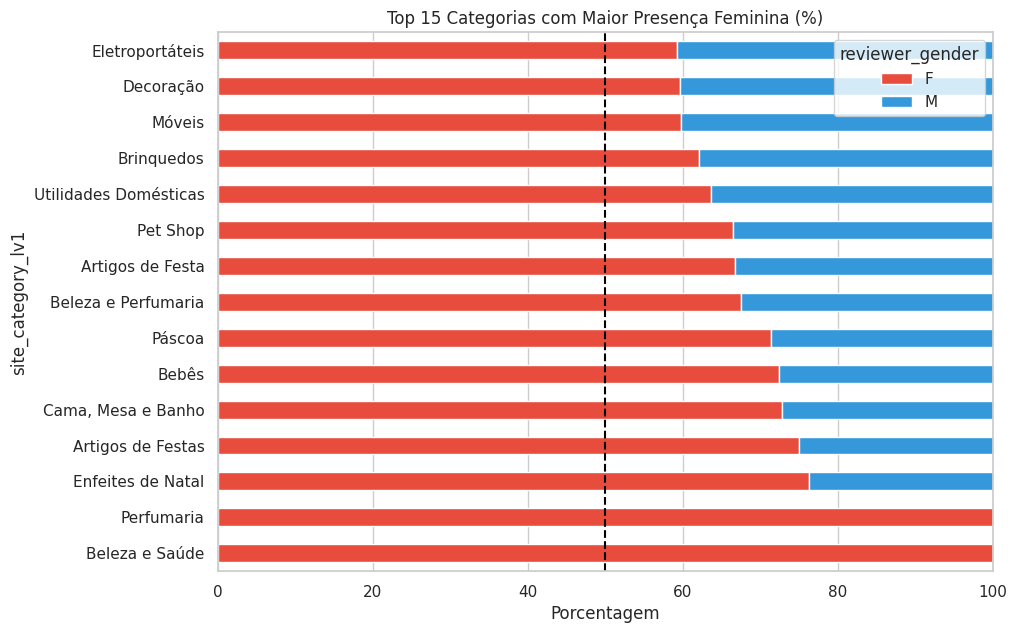

In [31]:
# Proporção de gênero por categoria
cat_gender_dist = pd.crosstab(df_train_eda['site_category_lv1'], df_train_eda['reviewer_gender'], normalize='index') * 100
cat_gender_dist = cat_gender_dist.sort_values(by='F', ascending=False).head(15)

cat_gender_dist.plot(kind='barh', stacked=True, figsize=(10, 7), color=['#e74c3c', '#3498db'])
plt.title('Top 15 Categorias com Maior Presença Feminina (%)')
plt.xlabel('Porcentagem')
plt.axvline(50, color='black', linestyle='--') # Linha de equilíbrio
plt.show()

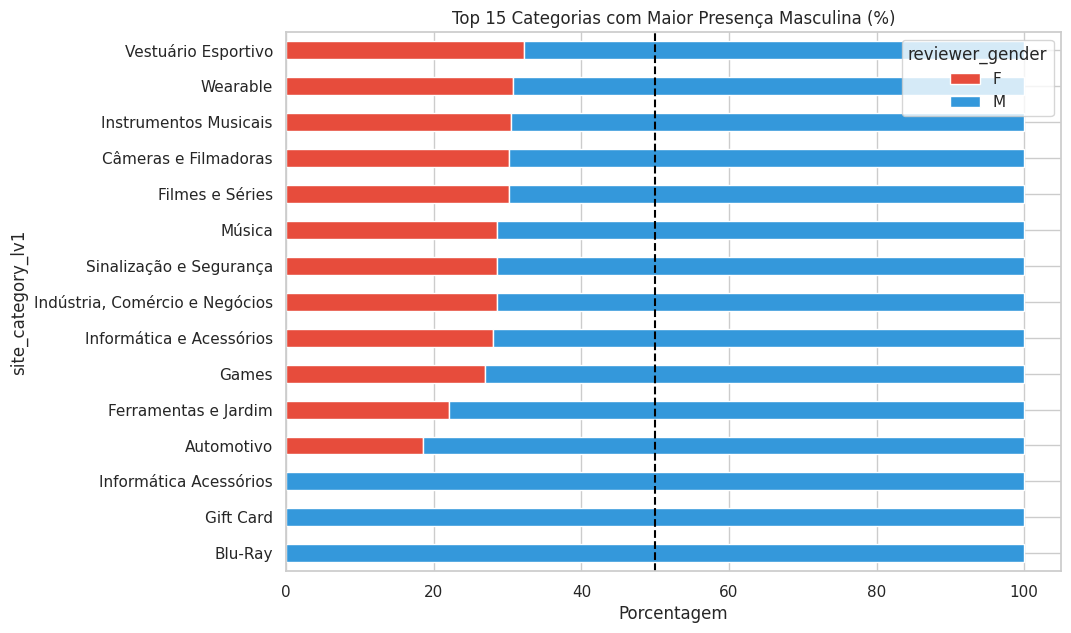

In [28]:
# Proporção de gênero por categoria
cat_gender_dist = pd.crosstab(df_train_eda['site_category_lv1'], df_train_eda['reviewer_gender'], normalize='index') * 100
cat_gender_dist = cat_gender_dist.sort_values(by='M', ascending=False).head(15)

cat_gender_dist.plot(kind='barh', stacked=True, figsize=(10, 7), color=['#e74c3c', '#3498db'])
plt.title('Top 15 Categorias com Maior Presença Masculina (%)')
plt.xlabel('Porcentagem')
plt.axvline(50, color='black', linestyle='--') # Linha de equilíbrio
plt.show()

### Q3: Gênero vs. Avaliação

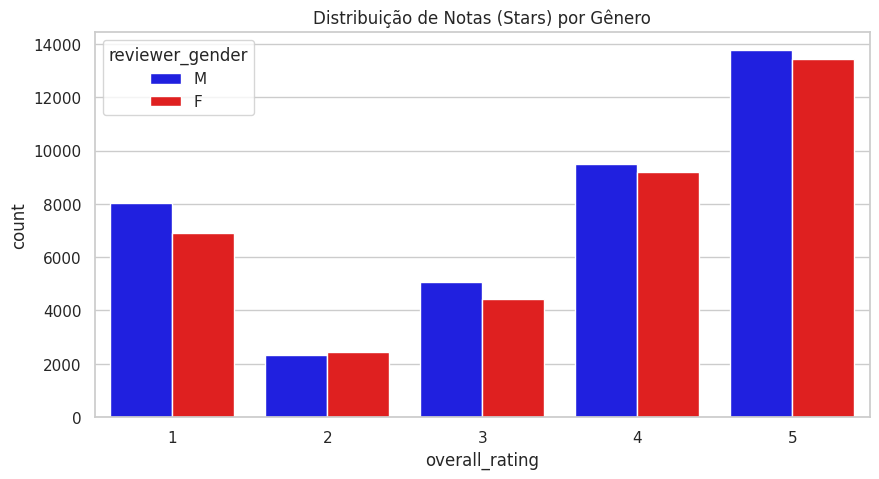

reviewer_gender
F    3.543199
M    3.482827
Name: overall_rating, dtype: float64


In [32]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_train_eda, x='overall_rating', hue='reviewer_gender', palette=['blue', 'red'])
plt.title('Distribuição de Notas (Stars) por Gênero')
plt.show()

# Médias exatas
print(df_train_eda.groupby('reviewer_gender')['overall_rating'].mean())

### Q4: Diferença estatística no tamanho das mensagens

Usando Mann-Whitney U (pois o tamanho de texto raramente segue uma distribuição normal).

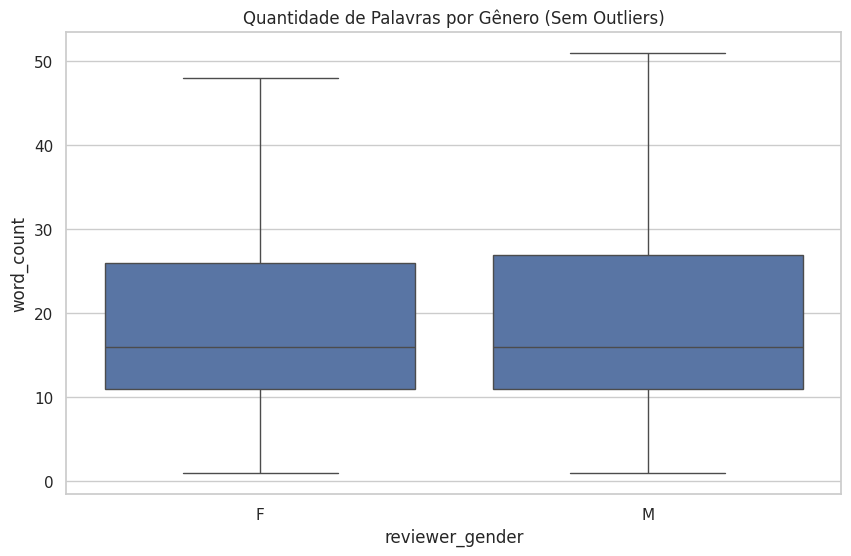

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_train_eda, x='reviewer_gender', y='word_count', showfliers=False)
plt.title('Quantidade de Palavras por Gênero (Sem Outliers)')
plt.show()

In [75]:
# Teste estatístico
males = df_train_eda[df_train_eda['reviewer_gender'] == 'M']['word_count']
females = df_train_eda[df_train_eda['reviewer_gender'] == 'F']['word_count']
stat, p = mannwhitneyu(males, females)

print(f"Mediana Masculina: {males.median()} | Mediana Feminina: {females.median()}")
print(f"P-valor do teste Mann-Whitney: {p:.5f}")

Mediana Masculina: 16.0 | Mediana Feminina: 16.0
P-valor do teste Mann-Whitney: 0.00069


## Conclusões Preliminares:
1. Q1: A marca do produto possui correlação com o gênero? Sim, aparentemente, há uma correlação.
2. Q2: Apresenta uma forte correlação
3. Q3: Não apresenta correlação
4. Q4: Como p < 0.5, posso dizer que sim, há uma diferença estatisticamente relevante entre a distribuição de wordcount por gênero

#### Outras Perguntas:
- Q5: Existe um gênero que tende a recomendar o produto mesmo dando notas baixas (3 ou 4)?
- Q6: O uso de múltiplas exclamações (ex: "Amei!!!") ou letras repetidas ("Linnnnndo") ou emojis é mais frequente em qual gênero?
- Q7: Há variação no volume de reviews entre janeiro e maio de 2018 para cada gênero? (ex: dia das mães, dia das mulheres ou dia dos pais).
- Q8: Como a idade (reviewer_birth_year) se distribui entre os gêneros?.

### Q5:

In [44]:
# Filtramos apenas as notas 3 e 4 (a "zona cinzenta" mencionada no artigo)
df_mid_ratings = df_train_eda[df_train_eda['overall_rating'].isin([3, 4])].copy()

# Calculamos a proporção
q5_crosstab = pd.crosstab(df_mid_ratings['reviewer_gender'], df_mid_ratings['recommend_to_a_friend'], normalize='index') * 100

print(q5_crosstab)

recommend_to_a_friend        No        Yes
reviewer_gender                           
F                      4.441671  95.558329
M                      5.147210  94.852790


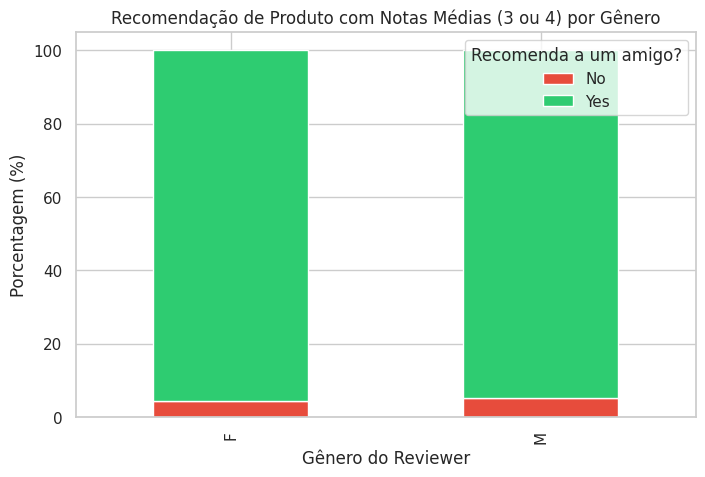

In [45]:
q5_crosstab.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#e74c3c', '#2ecc71'])
plt.title('Recomendação de Produto com Notas Médias (3 ou 4) por Gênero')
plt.ylabel('Porcentagem (%)')
plt.xlabel('Gênero do Reviewer')
plt.legend(title='Recomenda a um amigo?', loc='upper right')
plt.show()

### Q6: Uso de caracteres repetidos e pontuação excessiva (Análise Estilométrica)

In [46]:
# 1. Múltiplas pontuações seguidas (ex: !!!, ???, ..)
cspam = r'[!?\.]{2,}'
df_train_eda['multi_punct'] = df_train_eda['review_text'].str.contains(cspam, regex=True, na=False)

# 2. Letras repetidas 3 vezes ou mais (ex: ameeei, lindooo)
df_train_eda['repeated_letters'] = df_train_eda['review_text'].str.contains(r'([a-zA-Z])\1{2,}', regex=True, na=False)

# Agrupa e calcula a porcentagem de reviews que contêm esses padrões
style_analysis = df_train_eda.groupby('reviewer_gender')[['multi_punct', 'repeated_letters']].mean() * 100

print("Porcentagem de uso de estilos textuais:")
print(style_analysis)

/tmp/ipykernel_10766/2711003068.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_train_eda['repeated_letters'] = df_train_eda['review_text'].str.contains(r'([a-zA-Z])\1{2,}', regex=True, na=False)


Porcentagem de uso de estilos textuais:
                 multi_punct  repeated_letters
reviewer_gender                               
F                  17.414125          1.791701
M                  15.212331          1.414680


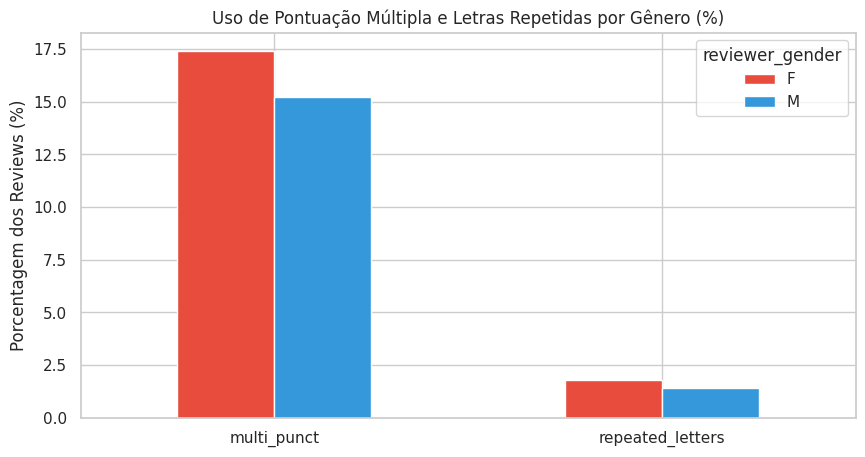

In [47]:
style_analysis.T.plot(kind='bar', figsize=(10, 5), color=['#e74c3c', '#3498db'])
plt.title('Uso de Pontuação Múltipla e Letras Repetidas por Gênero (%)')
plt.ylabel('Porcentagem dos Reviews (%)')
plt.xticks(rotation=0)
plt.show()

### Q6.1 Contagem de caracteres em caixa alta por gênero

In [134]:
df_train_eda['upper'] = df_train_eda['review_text'].str.count(r'\b[A-ZÀ-Ú]{2,}\b').values.astype(np.int32)
upper_analysis = df_train_eda.groupby('reviewer_gender')[['multi_punct', 'repeated_letters', 'upper']].mean() * 100
print(upper_analysis)

                 multi_punct  repeated_letters      upper
reviewer_gender                                          
F                  17.414125          1.791701  61.134927
M                  15.212331          1.414680  88.718771


In [167]:
up = (
    df_train_eda
    .groupby('reviewer_gender', group_keys=False)
    .apply(lambda g: g.nlargest(28, 'upper'))
    [['upper', 'review_text']]
    .reset_index(drop=True)
)
# up

### Q7: Variação no volume de reviews ao longo do tempo

In [48]:
# Converte a coluna para datetime
df_train_eda['date'] = pd.to_datetime(df_train_eda['submission_date'])

# Agrupa por semana para o gráfico não ficar muito ruidoso
df_train_eda['week'] = df_train_eda['date'].dt.to_period('W').apply(lambda r: r.start_time)

# Conta os reviews por semana e por gênero
timeline = df_train_eda.groupby(['week', 'reviewer_gender']).size().reset_index(name='count')

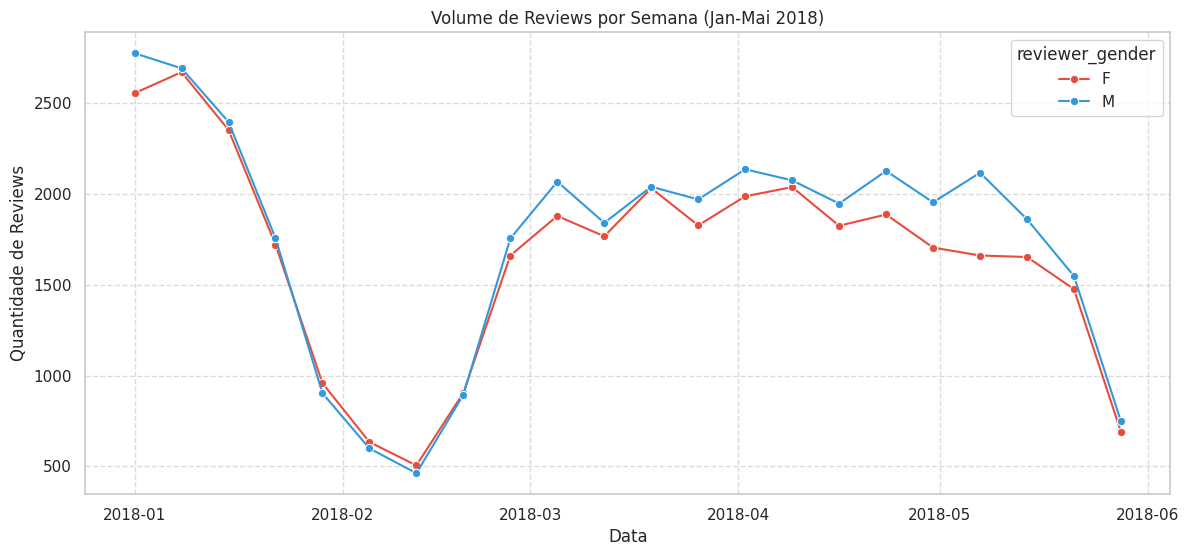

In [49]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=timeline, x='week', y='count', hue='reviewer_gender', palette=['#e74c3c', '#3498db'], marker='o')
plt.title('Volume de Reviews por Semana (Jan-Mai 2018)')
plt.ylabel('Quantidade de Reviews')
plt.xlabel('Data')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Q8: Distribuição de Idade por Gênero

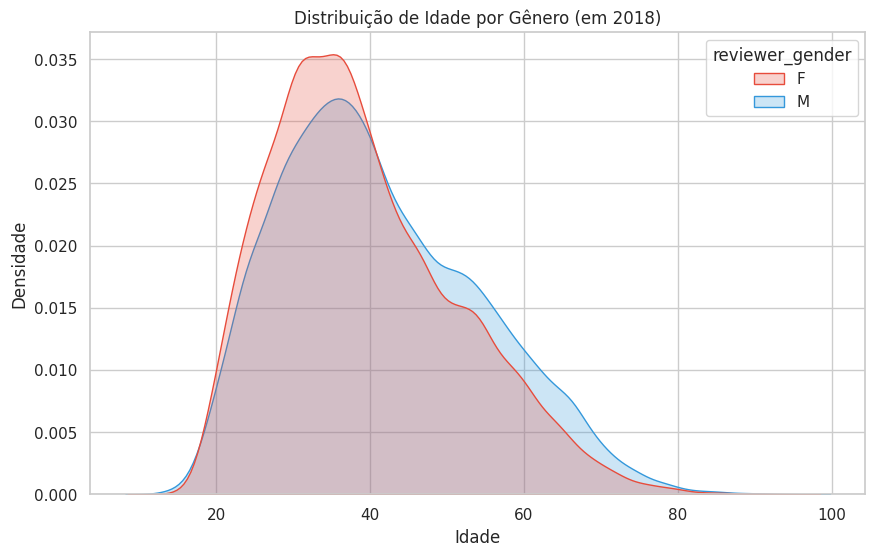

                   count       mean        std   min   25%   50%   75%   max
reviewer_gender                                                             
F                35799.0  39.138942  12.163478  13.0  30.0  37.0  47.0  94.0
M                38029.0  41.314786  13.113703  13.0  31.0  39.0  50.0  95.0


In [50]:
# Filtra anos de nascimento razoáveis (entre 1920 e 2005)
df_age = df_train_eda[(df_train_eda['reviewer_birth_year'] > 1920) & (df_train_eda['reviewer_birth_year'] <= 2005)].copy()

# Calcula a idade em 2018
df_age['age'] = 2018 - df_age['reviewer_birth_year']

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_age, x='age', hue='reviewer_gender', fill=True, common_norm=False, palette=['#e74c3c', '#3498db'])
plt.title('Distribuição de Idade por Gênero (em 2018)')
plt.xlabel('Idade')
plt.ylabel('Densidade')
plt.show()

print(df_age.groupby('reviewer_gender')['age'].describe())

### Resultados Q[5-8]:
- Q5: A diferença entre homens e mulheres ao recomendar um produto com nota média é ínfima (94,8% vs 95,5%) => Ambos tendem a recomendar. coluna recommend_to_a_friend pode ser descartada.
- Q6: Mulheres usam múltiplas pontuações (17,4% vs 15,2%) e letras repetidas (1,7% vs 1,4%) com um pouco mais de frequência. => Exige etapa de pre-processamento.
- Q7: A ausência de picos anômalos ou inversões de proporção entre os meses indica que o comportamento temporal é estável. => A coluna submission_date pode ser descartada.
- Q8: Os homens no dataset são, em média, 2 anos mais velhos que as mulheres (mediana de 39 vs 37). => A coluna reviewer_birth_year é um atributo secundário válido.

### Perguntas associadas a Heurística do Artigo - Módulos de dicionários:
- Q9: Quais são os termos mais discriminativos (Dicionário Latente) por gênero? => Construir diciońario
- Q10: Existe diferença na distribuição do volume de Classes Gramaticais (POS Tags)? (O artigo buscou a flexão do adjetivo.)

### Q9:

A melhor forma de fazer isso sem ter o viéz de remoção de stopwords ou contagem de palavras brutas é aplicando **Log Odds Ratio com Laplace Smoothing (Suavização de Laplace)**.

Essa métrica calcula a probabilidade de uma palavra aparecer em textos femininos versus masculinos.

Valores altos indicam termos fortemente femininos, e valores negativos indicam termos fortemente masculinos.

In [51]:
# 1. Download de stopwords (certifique-se de que o ambiente uv tem o nltk instalado)
nltk.download('stopwords', quiet=True)
stop_words_pt = stopwords.words('portuguese')

In [52]:
# Adicionando algumas stopwords específicas de e-commerce que não ajudam na discriminação
stop_words_pt.extend(['produto', 'comprei', 'veio', 'chegou', 'dia', 'loja', 'americanas', 'pra'])

Função de limpeza EXCLUSIVA para a Q9

In [53]:
# (Não use no pipeline final!)
def clean_for_eda(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # Mantém apenas letras (incluindo acentuadas) e espaços
    text = re.sub(r'[^a-zãõáéíóúâêîôûàèìòùç\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

Trabalhando em uma cópia segura para não alterar o df original

In [54]:
df_q9 = df_train_eda[['review_text', 'reviewer_gender']].dropna().copy()
df_q9['clean_text'] = df_q9['review_text'].apply(clean_for_eda)

In [55]:
# 3. Vetorização (Contagem pura de frequência)
# min_df=20 ignora palavras raras que apareceram em menos de 20 reviews
MIN_DF=20
vec = CountVectorizer(stop_words=stop_words_pt, min_df=MIN_DF)
X = vec.fit_transform(df_q9['clean_text'])
words = vec.get_feature_names_out()

In [56]:
# Separar as matrizes de contagem por gênero
mask_F = (df_q9['reviewer_gender'] == 'F').values
mask_M = (df_q9['reviewer_gender'] == 'M').values

In [57]:
# 4. Somar frequências aplicando Laplace Smoothing (+1) para evitar divisão por zero
word_counts_F = np.asarray(X[mask_F].sum(axis=0)).flatten() + 1
word_counts_M = np.asarray(X[mask_M].sum(axis=0)).flatten() + 1

In [58]:
# Frequência relativa (normalizada pelo volume total de palavras do gênero)
total_F = word_counts_F.sum()
total_M = word_counts_M.sum()

In [59]:
freq_rel_F = word_counts_F / total_F
freq_rel_M = word_counts_M / total_M

In [60]:
# 5. Calcular o Log Odds Ratio
# > 0 (viés Feminino), < 0 (viés Masculino)
log_odds = np.log(freq_rel_F / freq_rel_M)

In [61]:
# Criar DataFrame consolidado
df_words = pd.DataFrame({
    'palavra': words,
    'log_odds': log_odds,
    'count_F': word_counts_F - 1, # removendo o smoothing para visualização real
    'count_M': word_counts_M - 1
})

In [62]:
# Filtro de relevância: analisar apenas palavras com mais de 100 aparições totais
MIN_OCC = 100
df_words = df_words[(df_words['count_F'] + df_words['count_M']) > MIN_OCC]

In [63]:
# Pegar as Top N de cada lado
TOP = 30
top_fem = df_words.nlargest(TOP, 'log_odds')
top_masc = df_words.nsmallest(TOP, 'log_odds').copy()
top_masc['log_odds_abs'] = abs(top_masc['log_odds']) # Valor absoluto para o gráfico

/tmp/ipykernel_10766/3886855945.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_fem, x='log_odds', y='palavra', palette='Reds_r')
/tmp/ipykernel_10766/3886855945.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_masc, x='log_odds_abs', y='palavra', palette='Blues_r')


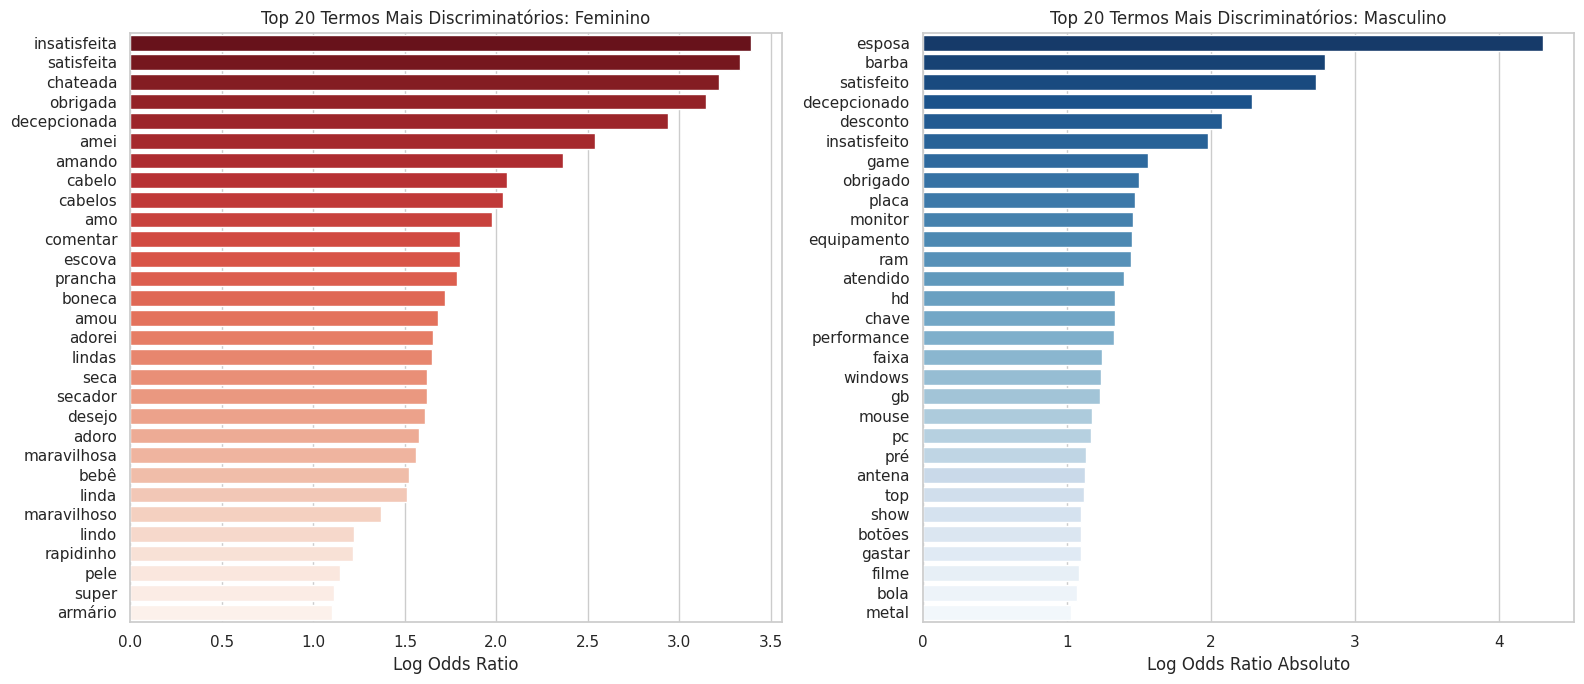

In [64]:
# 6. Visualização
plt.figure(figsize=(16, 7))

# Gráfico Feminino
plt.subplot(1, 2, 1)
sns.barplot(data=top_fem, x='log_odds', y='palavra', palette='Reds_r')
plt.title('Top 20 Termos Mais Discriminatórios: Feminino')
plt.xlabel('Log Odds Ratio')
plt.ylabel('')

# Gráfico Masculino
plt.subplot(1, 2, 2)
sns.barplot(data=top_masc, x='log_odds_abs', y='palavra', palette='Blues_r')
plt.title('Top 20 Termos Mais Discriminatórios: Masculino')
plt.xlabel('Log Odds Ratio Absoluto')
plt.ylabel('')

plt.tight_layout()
plt.show()

In [71]:
print(top_masc.nlargest(28, 'log_odds'))

           palavra  log_odds  count_F  count_M  log_odds_abs
2333         metal -1.027596       26       83      1.027596
488           bola -1.073467       34      113      1.073467
1661         filme -1.087243       42      141      1.087243
514         botões -1.096589       35      119      1.096589
1811        gastar -1.096589       26       89      1.096589
3415          show -1.101577       79      267      1.101577
3635           top -1.117912      115      394      1.117912
217         antena -1.124760       27       95      1.124760
3012           pré -1.131681       41      144      1.131681
2668            pc -1.168910       35      128      1.168910
2392         mouse -1.178267       46      169      1.178267
1818            gb -1.228900       81      311      1.228900
3909       windows -1.236351       35      137      1.236351
1574         faixa -1.247162       23       92      1.247162
2727   performance -1.329683       23      100      1.329683
680          chave -1.33

In [72]:
print(top_fem.nlargest(28, 'log_odds'))

           palavra  log_odds  count_F  count_M
2013  insatisfeita  3.389234      212        7
3346    satisfeita  3.333293     1283       50
677       chateada  3.216444      111        4
2520      obrigada  3.145391      458       21
1041  decepcionada  2.938416      457       26
186           amei  2.536818     1384      121
173         amando  2.366166      133       13
547         cabelo  2.060630      683       96
548        cabelos  2.035826      226       32
196            amo  1.974650      109       16
764       comentar  1.801979       97       17
1421        escova  1.799770      200       36
2866       prancha  1.785030       90       16
499         boneca  1.716821      179       35
198           amou  1.678773      360       74
90          adorei  1.653517     1468      312
2176        lindas  1.650130      144       30
3354          seca  1.619972      117       25
3355       secador  1.619366      126       27
1116        desejo  1.611461       98       21
91           

#### Conclusão preliminar do Q9:
- As pessoas utilizam a primeira pessoa do singular e flexionam o adjetivo/particípio para o seu próprio gênero na hora de avaliar.
- A categoria do produto (validado na Q2) reflete diretamente no vocabulário usado no texto.

### Q10: : A proporção de uso de certas classes gramaticais varia por gênero?

Como os homens citaram muitas **especificações técnicas (RAM, HD, PC)** e as mulheres focaram em **percepções e ações (Amei, Adorei, Maravilhosa)**:

H: Homens usam mais Substantivos (NOUN) e Nomes Próprios (PROPN), enquanto mulheres usam mais Verbos (VERB) e Adjetivos (ADJ).

In [83]:
def extract_pos_counts(texts):
    pos_counts = []
    # nlp.pipe processa em lotes, o que é muito mais rápido
    for doc in tqdm(nlp.pipe(texts, batch_size=500), total=len(texts)):
        counts = {'NOUN': 0, 'ADJ': 0, 'VERB': 0, 'PROPN': 0}
        for token in doc:
            if token.pos_ in counts:
                counts[token.pos_] += 1
                
        # Normalização: calcular a proporção em relação ao tamanho do texto
        # Adiciona +1 no denominador para evitar divisão por zero em textos vazios
        total_tokens = len(doc) + 1
        pos_counts.append({
            'noun_ratio': counts['NOUN'] / total_tokens,
            'adj_ratio': counts['ADJ'] / total_tokens,
            'verb_ratio': counts['VERB'] / total_tokens,
            'propn_ratio': counts['PROPN'] / total_tokens
        })
    return pd.DataFrame(pos_counts)

In [93]:
txt = df_train_eda['review_text'].fillna("")
df_pos_train = extract_pos_counts(txt)
df_train_eda = pd.concat([df_train_eda.reset_index(drop=True), df_pos_train], axis=1)

100%|██████████| 75056/75056 [01:10<00:00, 1057.35it/s]


In [94]:
counts = ['noun_ratio', 'adj_ratio', 'verb_ratio', 'propn_ratio']
res = df_train_eda.groupby('reviewer_gender')[counts]
print(res.mean())

                 noun_ratio  noun_ratio  noun_ratio  adj_ratio  adj_ratio  \
reviewer_gender                                                             
F                  0.182560    0.182560    0.181952   0.082689   0.082689   
M                  0.187497    0.187497    0.189385   0.078551   0.078551   

                 adj_ratio  verb_ratio  verb_ratio  verb_ratio  propn_ratio  \
reviewer_gender                                                               
F                 0.081523    0.134323    0.134323    0.135047     0.025205   
M                 0.079216    0.126663    0.126663    0.126402     0.033911   

                 propn_ratio  propn_ratio  
reviewer_gender                            
F                   0.025205     0.026356  
M                   0.033911     0.033493  


#### Análise dos Resultados de Q10:
- Masculino (noun_ratio e propn_ratio maiores): Foco em objetos, entidades e especificações técnicas (Nomes Próprios e Substantivos). Eles avaliam o que o produto é.
- Feminino (adj_ratio e verb_ratio maiores): Foco em qualidades, percepções e ações (Adjetivos e Verbos). Elas avaliam como se sentiram com o produto ou o serviço.

H: VERDADEIRA!

### Conclusões das Análises "Q":
As features mais relevantes para inferir o gênero são:
- A Categoria do Produto (site_category_lv1): A separação de interesse é nítida (ex: Beleza vs. Hardware).
- O Texto Limpo (com Flexões): TF-IDF do texto, mantendo a gramática que indica gênero ("obrigada" vs "obrigado").
- Features de POS-TAG: Relação de Adjetivos, Verbos, Substantivos e Nomes Próprios.
- Estilometria (Q6): Contagem de múltiplas pontuações (!!!), uppercase e letras repetidas (ameeei).
- Idade (reviewer_birth_year): Feature de apoio.

## 3. Pré-Processamento

blablabla

In [ ]:
# Limpeza, normalização, etc.
def preprocessar(texto: str):
    # Seu código aqui
    texto_processado = texto.lower()
    return texto_processado

X_train_clean = df_train['review_text'].apply(preprocessar)

## 4. Representação Textual

In [ ]:
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train_clean)

## 5. Treinamento

In [ ]:
model = LogisticRegression()
model.fit(X_train_vec, y_train)

## 6. Validação e Métricas

In [ ]:
y_pred = model.predict(X_val_vec)
f1 = f1_score(y_val, y_pred, average='weighted')
print(f"F1 Score: {f1:.4f}")

## 7. Salvar Modelo

In [ ]:
def save_model(model, filename: str, path = './output/'):
  localefile = path + filename + '.pkl'
  pickle.dump(model, open(localefile, 'wb'))
  print("✓ Modelo salvo!")

## 8. Conclusões

- Melhor F1 Score alcançado: 0.XXXX
- Principais desafios: ...
- Possíveis melhorias: ...